# assignment four

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8  # m/s^2


## task one

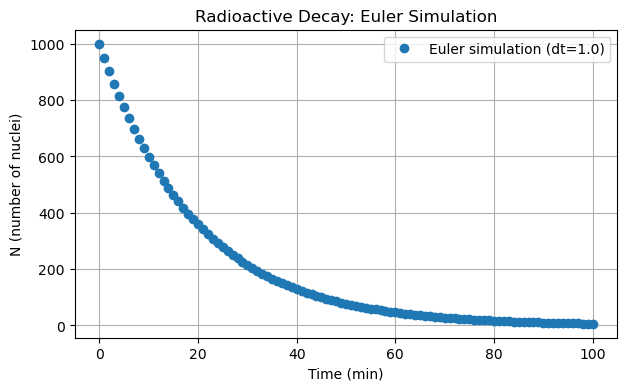

In [2]:
# Parameters
N0 = 1000
lam = 0.05  # min^-1
dt = 1.0    # min
t_max = 100 # min

# Initialize
t = 0.0
N = N0

t_list = [t]
N_list = [N]

# Euler stepping
while t < t_max:
    dNdt = -lam * N
    dN = dNdt * dt
    N += dN
    t += dt
    t_list.append(t)
    N_list.append(N)

# Convert
t_arr = np.array(t_list)
N_arr = np.array(N_list)

# Plot simulation
plt.figure(figsize=(7,4))
plt.plot(t_arr, N_arr, 'o', label='Euler simulation (dt=1.0)')
plt.xlabel('Time (min)')
plt.ylabel('N (number of nuclei)')
plt.title('Radioactive Decay: Euler Simulation')
plt.grid(True)
plt.legend()
plt.show()


## task two

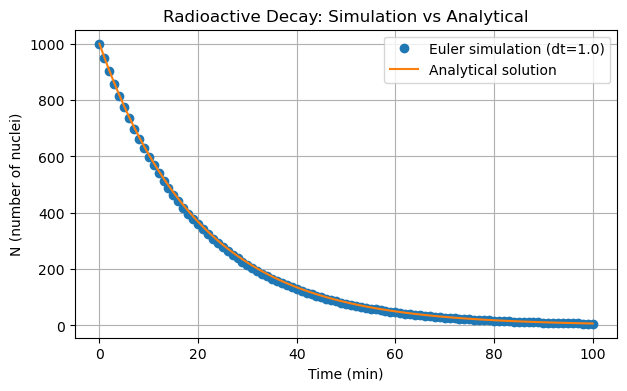

In [3]:
# Analytical solution
N_analytic = N0 * np.exp(-lam * t_arr)

plt.figure(figsize=(7,4))
plt.plot(t_arr, N_arr, 'o', label='Euler simulation (dt=1.0)')
plt.plot(t_arr, N_analytic, '-', label='Analytical solution')
plt.xlabel('Time (min)')
plt.ylabel('N (number of nuclei)')
plt.title('Radioactive Decay: Simulation vs Analytical')
plt.grid(True)
plt.legend()
plt.show()


For comparison in the Euler simulation dot plot grew in density over time while the analytic solution was a consistant line.

## task three

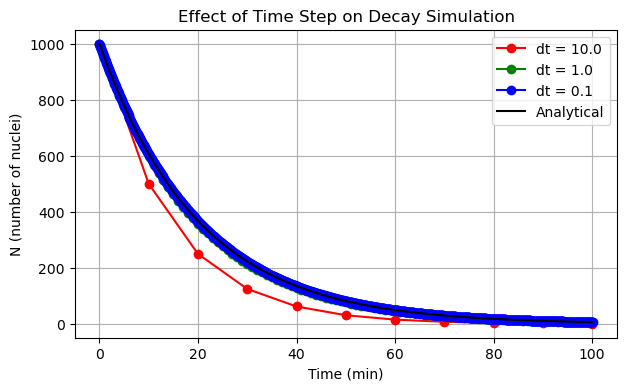

In [4]:
def decay_euler(N0, lam, dt, t_max):
    t = 0.0
    N = N0
    t_list = [t]
    N_list = [N]
    while t < t_max:
        dNdt = -lam * N
        N += dNdt * dt
        t += dt
        t_list.append(t)
        N_list.append(N)
    return np.array(t_list), np.array(N_list)

dt_values = [10.0, 1.0, 0.1]
colors = ['r', 'g', 'b']
labels = [f'dt = {dt}' for dt in dt_values]

plt.figure(figsize=(7,4))
for dt, c, lab in zip(dt_values, colors, labels):
    t_sim, N_sim = decay_euler(N0, lam, dt, t_max)
    plt.plot(t_sim, N_sim, 'o-', color=c, label=lab)

# Analytical
t_fine = np.linspace(0, t_max, 1000)
N_fine = N0 * np.exp(-lam * t_fine)
plt.plot(t_fine, N_fine, 'k-', label='Analytical')

plt.xlabel('Time (min)')
plt.ylabel('N (number of nuclei)')
plt.title('Effect of Time Step on Decay Simulation')
plt.grid(True)
plt.legend()
plt.show()


## task four

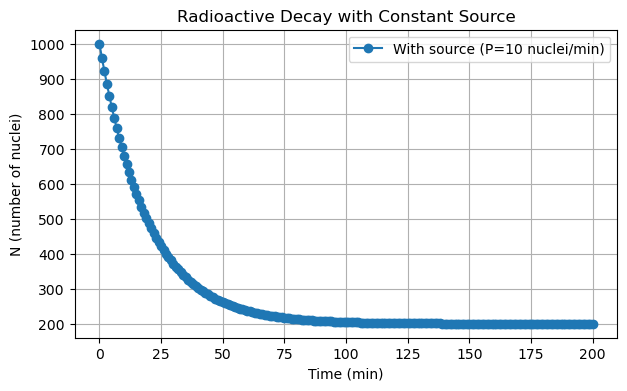

200.0

In [5]:
# Parameters with source
P = 10.0      # nuclei/min
lam = 0.05    # min^-1
dt = 1.0
t_max = 200.0

t = 0.0
N = N0

t_list = [t]
N_list = [N]

while t < t_max:
    dNdt = P - lam * N
    N += dNdt * dt
    t += dt
    t_list.append(t)
    N_list.append(N)

t_arr_src = np.array(t_list)
N_arr_src = np.array(N_list)

plt.figure(figsize=(7,4))
plt.plot(t_arr_src, N_arr_src, 'o-', label='With source (P=10 nuclei/min)')
plt.xlabel('Time (min)')
plt.ylabel('N (number of nuclei)')
plt.title('Radioactive Decay with Constant Source')
plt.grid(True)
plt.legend()
plt.show()

# Steady-state value from theory: P = λ N_ss -> N_ss = P / λ
N_ss_theory = P / lam
N_ss_theory


## Question Two

In [6]:
def projectile_euler(v0, theta_deg, dt, b=0.0, m=1.0, g=9.8):
    theta = np.radians(theta_deg)
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    x, y = 0.0, 0.0

    x_list, y_list = [x], [y]

    while y >= 0:
        # acceleration
        ax = -b * vx / m
        ay = -g - b * vy / m

        # Euler update
        x = x + vx * dt
        y = y + vy * dt
        vx = vx + ax * dt
        vy = vy + ay * dt

        x_list.append(x)
        y_list.append(y)

    return np.array(x_list), np.array(y_list)

def projectile_euler_cromer(v0, theta_deg, dt, b=0.0, m=1.0, g=9.8):
    theta = np.radians(theta_deg)
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    x, y = 0.0, 0.0

    x_list, y_list = [x], [y]

    while y >= 0:
        # acceleration
        ax = -b * vx / m
        ay = -g - b * vy / m

        # Euler–Cromer: update v first, then position
        vx = vx + ax * dt
        vy = vy + ay * dt
        x = x + vx * dt
        y = y + vy * dt

        x_list.append(x)
        y_list.append(y)

    return np.array(x_list), np.array(y_list)


## task one

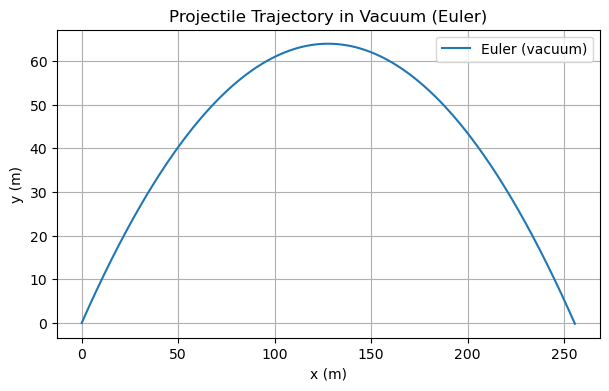

In [7]:
v0 = 50.0      # m/s
theta0 = 45.0  # degrees
dt = 0.01      # s

# Euler in vacuum
x_vac, y_vac = projectile_euler(v0, theta0, dt, b=0.0)

# Landing distance from simulation
R_sim = x_vac[-1]

# Theoretical range
R_theory = v0**2 * np.sin(2 * np.radians(theta0)) / g

R_sim, R_theory

# Plot trajectory
plt.figure(figsize=(7,4))
plt.plot(x_vac, y_vac, label='Euler (vacuum)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory in Vacuum (Euler)')
plt.grid(True)
plt.legend()
plt.show()


## task two

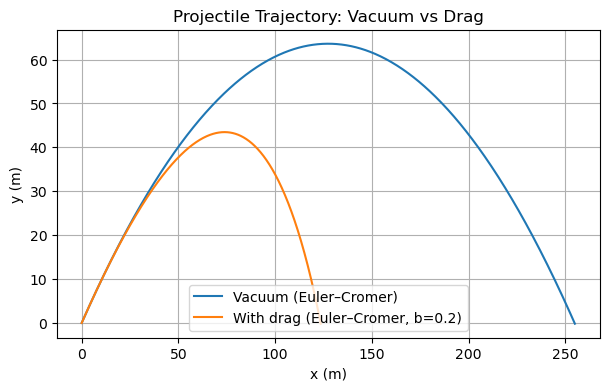

In [8]:
dt = 0.01
b = 0.2  # linear drag coefficient

# Vacuum (Euler–Cromer)
x_vac_ec, y_vac_ec = projectile_euler_cromer(v0, theta0, dt, b=0.0)

# With drag (Euler–Cromer)
x_drag, y_drag = projectile_euler_cromer(v0, theta0, dt, b=b)

plt.figure(figsize=(7,4))
plt.plot(x_vac_ec, y_vac_ec, label='Vacuum (Euler–Cromer)')
plt.plot(x_drag, y_drag, label='With drag (Euler–Cromer, b=0.2)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory: Vacuum vs Drag')
plt.grid(True)
plt.legend()
plt.show()


## task three

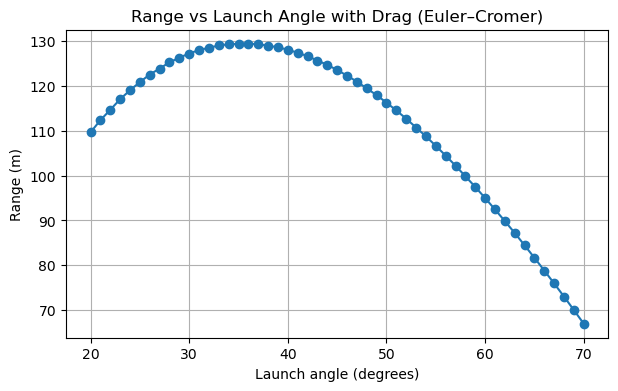

In [9]:
angles = np.arange(20, 71, 1)  # 20° to 70°
ranges = []

dt = 0.01
b = 0.2

for theta in angles:
    x_traj, y_traj = projectile_euler_cromer(v0, theta, dt, b=b)
    ranges.append(x_traj[-1])

ranges = np.array(ranges)
best_index = np.argmax(ranges)
best_angle = angles[best_index]
best_range = ranges[best_index]

best_angle, best_range

# Plot range vs angle
plt.figure(figsize=(7,4))
plt.plot(angles, ranges, 'o-')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Launch Angle with Drag (Euler–Cromer)')
plt.grid(True)
plt.show()




# Question Three

In [10]:
K = 0.05       # min^-1
T_env = 20.0   # °C
T0 = 90.0      # °C
dt = 2.0       # min (large on purpose)
t_max = 60.0   # min

def cooling_euler(T0, K, T_env, dt, t_max):
    t = 0.0
    T = T0
    t_list = [t]
    T_list = [T]
    while t < t_max:
        dTdt = -K * (T - T_env)
        T += dTdt * dt
        t += dt
        t_list.append(t)
        T_list.append(T)
    return np.array(t_list), np.array(T_list)

t_euler, T_euler = cooling_euler(T0, K, T_env, dt, t_max)


## task two

In [11]:
def cooling_RK4(T0, K, T_env, dt, t_max):
    def f(T):
        return -K * (T - T_env)
    
    t = 0.0
    T = T0
    t_list = [t]
    T_list = [T]
    
    while t < t_max:
        k1 = f(T)
        k2 = f(T + 0.5 * dt * k1)
        k3 = f(T + 0.5 * dt * k2)
        k4 = f(T + dt * k3)
        
        T = T + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t += dt
        t_list.append(t)
        T_list.append(T)
    
    return np.array(t_list), np.array(T_list)

t_rk4, T_rk4 = cooling_RK4(T0, K, T_env, dt, t_max)


## task three

In [12]:
# Interpolate analytical at Euler/RK4 times up to 10 min
mask_10 = t_euler <= 10.0
t_10 = t_euler[mask_10]

T_analytic_10 = T_env + (T0 - T_env) * np.exp(-K * t_10)

error_euler_10 = T_euler[mask_10] - T_analytic_10
error_rk4_10 = T_rk4[mask_10] - T_analytic_10

error_euler_10, error_rk4_10


(array([ 0.        , -0.33861926, -0.61115272, -0.82727545, -0.99540322,
        -1.12284618]),
 array([0.00000000e+00, 5.73748282e-06, 1.03829788e-05, 1.40923622e-05,
        1.70017296e-05, 1.92297522e-05]))

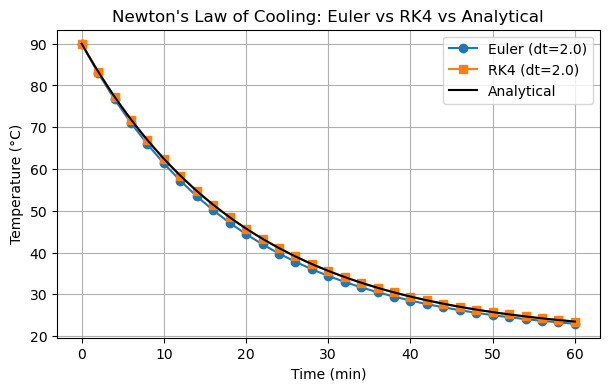

In [13]:
# Analytical solution
t_fine = np.linspace(0, t_max, 1000)
T_analytic = T_env + (T0 - T_env) * np.exp(-K * t_fine)

plt.figure(figsize=(7,4))
plt.plot(t_euler, T_euler, 'o-', label='Euler (dt=2.0)')
plt.plot(t_rk4, T_rk4, 's-', label='RK4 (dt=2.0)')
plt.plot(t_fine, T_analytic, 'k-', label='Analytical')
plt.xlabel('Time (min)')
plt.ylabel('Temperature (°C)')
plt.title("Newton's Law of Cooling: Euler vs RK4 vs Analytical")
plt.grid(True)
plt.legend()
plt.show()


questions: The RK4 is closer to the exact solution than the Euler Method
From the error plot the Euler Method is off only by less than 5 degrees Celsius